In [174]:
from typing import Dict, List, Optional
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.messages import AIMessage
from langchain_community.tools import DuckDuckGoSearchResults as DDGS
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_groq import ChatGroq
import json
import os
import dotenv
import re
from datetime import datetime, timedelta

In [175]:
dotenv.load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [176]:
wrapper = DuckDuckGoSearchAPIWrapper(time="w", max_results=15)
tool = DDGS(backend="news",api_wrapper=wrapper)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.ddg_search.tool.DuckDuckGoSearchResults'>
duckduckgo_results_json


In [177]:


class NewsState(TypedDict):
    topic: str 
    raw_articles: List[Dict] 
    curated_articles: List[Dict] 
    fact_checked_articles: List[Dict] 
    structured_articles: List[Dict] 
    qa_report: Dict 
    final_output: Optional[Dict] 

class NewsWorkflow:
    def __init__(self, model, tools):
        self.model = model.bind_tools(tools)
        self.tools = {t.name: t for t in tools}
        
        graph = StateGraph(NewsState)
        
        # Add nodes
        graph.add_node("content_curation", self.curate_content)
        graph.add_node("fact_checking", self.fact_check)
        graph.add_node("structuring", self.structure_content)
        graph.add_node("quality_assurance", self.quality_check)
        graph.add_node("supervisor", self.supervise)
        
        # Add edges
        graph.add_edge("content_curation", "fact_checking")
        graph.add_edge("fact_checking", "structuring")
        graph.add_edge("structuring", "quality_assurance")
        graph.add_edge("quality_assurance", "supervisor")
        
        # Add conditional edges for revision
        graph.add_conditional_edges(
            "supervisor",
            self.needs_revision,
            {
                True: "content_curation",
                False: END
            }
        )
        
        graph.set_entry_point("content_curation")
        self.graph = graph.compile()

    def curate_content(self, state: NewsState) -> NewsState:
    # Search for articles
        print("in Curate Contest")
        search_prompt = f"Find the latest news articles about {state['topic']} from the past week using duckduckgo_results_json"
        search_results = self.model.invoke(search_prompt)
        
        raw_articles = []
        for call in search_results.tool_calls:
            results = self.tools[call['name']].invoke(call['args'])
            raw_articles.extend(results if isinstance(results, list) else [results])
        
        # Modify curation prompt to ensure direct JSON response
        curation_prompt = f"""Analyze and curate these articles about '{state['topic']}':
        {json.dumps(raw_articles, indent=2)}

        Create a JSON array containing only high-quality, factual articles. Each article should be a JSON object with this exact structure:
            "title": "Full article title",
            "url": "Complete article URL",
            "date": "Publication date in YYYY-MM-DD format",
            "content": "Main article content or summary",
            "source": "Publication source name"
    

        Respond with ONLY the JSON array. Do not include any other text or explanation."""
        
        try:
            response = self.model.invoke(curation_prompt)
            if hasattr(response, 'content'):
                content = response.content
            else:
                content = str(response)
                
            # Handle potential string formatting
            if isinstance(content, str):
                # Remove any potential markdown code block markers
                content = content.strip('`').strip()
                if content.startswith('json'):
                    content = content[4:].strip()
                    
            state['curated_articles'] = json.loads(content)
            
        except json.JSONDecodeError as e:
            print(f"JSON parsing error: {e}")
            print(f"Raw response: {response}")
            state['curated_articles'] = []
            
        return state

    def fact_check(self, state: NewsState) -> NewsState:
        print("in fact check")
        if not state['curated_articles']:
            print("No curated articles to fact check")
            state['fact_checked_articles'] = []
            return state

        fact_check_prompt = f"""You are a fact-checking system. Analyze these articles for accuracy WITHOUT using any external tools or searches:

        {json.dumps(state['curated_articles'], indent=2)}

        Create a JSON array where each article includes fact-checking results. Required structure for each article:
        {{
            "title": "Original article title",
            "verification_status": "True/False/Partially True",
            "evidence": "Your analysis of the claims based on provided content",
            "confidence_score": <number between 0-100>,
            "key_claims": ["List of main claims from the article"],
            "metadata": {{
                "original_url": "Article URL",
                "source": "Original source name",
                "date_published": "Original publication date"
            }}
        }}

        Important:
        1. Base your analysis ONLY on the provided content
        2. DO NOT perform external searches
        3. Return ONLY the JSON array
        4. No additional text or explanations
        5. No tool usage
        """

        try:
            # Create a model instance without tools
            model_no_tools = self.model.bind_tools([])
            
            response = model_no_tools.invoke(fact_check_prompt)
            content = response.content if hasattr(response, 'content') else str(response)
            
            # Clean the response
            if isinstance(content, str):
                # Remove tool-use tags and find JSON content
                content = re.sub(r'<[^>]+>', '', content)
                content = content.strip()
                
                # Find the first [ and last ]
                start = content.find('[')
                end = content.rfind(']') + 1
                if start >= 0 and end > start:
                    content = content[start:end]
                else:
                    # If no array found, try to find object and wrap it
                    start = content.find('{')
                    end = content.rfind('}') + 1
                    if start >= 0 and end > start:
                        content = f"[{content[start:end]}]"
                
                # Remove any markdown formatting
                content = re.sub(r'```json\s*|\s*```', '', content)
                
                # Clean up any trailing commas before closing brackets
                content = re.sub(r',(\s*[}\]])', r'\1', content)
                
            # Parse JSON
            fact_checked = json.loads(content)
            
            # Ensure we have a list
            if isinstance(fact_checked, dict):
                if 'articles' in fact_checked:
                    fact_checked = fact_checked['articles']
                else:
                    fact_checked = [fact_checked]
            
            # Validate structure
            required_fields = ['title', 'verification_status', 'evidence', 'confidence_score']
            for article in fact_checked:
                if not all(field in article for field in required_fields):
                    raise ValueError(f"Missing required fields in article: {article.get('title', 'Unknown')}")
            
            state['fact_checked_articles'] = fact_checked
            
        except json.JSONDecodeError as e:
            print(f"JSON parsing error in fact_check: {e}")
            print(f"Raw response: {content}")
            state['fact_checked_articles'] = []
        except Exception as e:
            print(f"Error in fact_check: {str(e)}")
            state['fact_checked_articles'] = []
        
        return state
    def structure_content(self, state: NewsState) -> NewsState:
        print("in structure Content")
        if not state['fact_checked_articles']:
            print("No fact-checked articles to structure")
            state['structured_articles'] = []
            return state
            
        structure_prompt = f"""You are a news content structuring system. Your task is to structure and summarize the following fact-checked articles, maintaining all key information in a standardized format.

        Input articles:
        {json.dumps(state['fact_checked_articles'], indent=2)}

        Instructions:
        1. Process each article into a structured format
        2. Create 100-word summaries focusing on key information
        3. Extract main facts and supporting evidence
        4. Maintain all metadata and verification information
        5. DO NOT perform any external searches or use any tools

        Required output format - respond with ONLY a JSON array where each article has this structure:
        {{
            "title": "Original article title",
            "summary": "100-word summary of key points",
            "key_facts": ["Array of important facts from article"],
            "reliability_score": "Original reliability score",
            "metadata": {{
                "original_url": "Original URL",
                "source": "Original source",
                "date_published": "Original date",
                "verification_status": "Original verification status",
                "confidence_score": "Original confidence score"
            }}
        }}

        Return the JSON array with no additional text, explanation, or tool usage."""
        
        try:
            response = self.model.invoke(
                structure_prompt,
                tools=[],  # Explicitly pass empty tools list
            )
            
            if hasattr(response, 'content'):
                content = response.content
            else:
                content = str(response)
                
            # Handle potential string formatting
            if isinstance(content, str):
                content = content.strip('`').strip()
                if content.startswith('json'):
                    content = content[4:].strip()
                
                # Additional cleanup for common formatting issues
                if not content.startswith('['):
                    content = content[content.find('['):]
                if not content.endswith(']'):
                    content = content[:content.rfind(']')+1]
                    
            structured_articles = json.loads(content)
            
            # Validate the structure of each article
            for article in structured_articles:
                required_fields = ['title', 'summary', 'key_facts', 'reliability_score', 'metadata']
                if not all(field in article for field in required_fields):
                    raise ValueError("Invalid article structure")
                    
            state['structured_articles'] = structured_articles
            
        except json.JSONDecodeError as e:
            print(f"JSON parsing error in structure_content: {e}")
            print(f"Raw response: {response}")
            state['structured_articles'] = []
        except ValueError as e:
            print(f"Validation error in structure_content: {e}")
            state['structured_articles'] = []
        except Exception as e:
            print(f"Unexpected error in structure_content: {e}")
            print(f"Raw response: {response}")
            state['structured_articles'] = []
        
        return state

    def quality_check(self, state: NewsState) -> NewsState:
        print("in quality check")
        if not state['structured_articles']:
            print("No structured articles to quality check")
            state['qa_report'] = {"status": "FAILED", "errors": ["No articles to check"]}
            return state

        # Create a list of simplified article data for the prompt
        articles_summary = []
        for article in state['structured_articles']:
            articles_summary.append({
                "title": article["title"],
                "source": article["metadata"]["source"],
                "date": article["metadata"]["date_published"],
                "reliability_score": article.get("reliability_score", 0)
            })

        qa_prompt = f"""Role: You are a news quality assessment system. Analyze these articles WITHOUT using any external tools or searches.

    Articles to analyze:
    {json.dumps(articles_summary, indent=2)}

    Task: Generate a quality assessment report in the specified JSON format below. Use ONLY the information provided.

    Required JSON structure:
    {{
        "status": "PASS or FAIL",
        "metrics": {{
            "total_articles": <number>,
            "articles_within_7_days": <number>,
            "unique_sources": <number>,
            "average_reliability_score": <number>
        }},
        "issues": {{
            "insufficient_articles": true/false,
            "outdated_articles": [],
            "duplicate_content": [],
            "low_reliability": []
        }},
        "source_analysis": {{
            "source_distribution": {{}},
            "reliability_summary": "text description"
        }},
        "recommendations": []
    }}

    Important: 
    1. Process ONLY the provided articles
    2. DO NOT perform any searches
    3. Return ONLY the JSON object
    4. No additional text or explanations
    5. No markdown formatting"""

        try:
            # Create a new model instance without tools
            model_no_tools = self.model.bind_tools([])
            
            response = model_no_tools.invoke(qa_prompt)
            
            content = response.content if hasattr(response, 'content') else str(response)
                
            # Clean up the response
            if isinstance(content, str):
                content = content.strip()
                if content.startswith('```'):
                    content = content[content.find('{'):content.rfind('}')+1]
                content = content.strip('`').strip()
                if content.startswith('json'):
                    content = content[4:].strip()
                    
            # Parse JSON
            qa_report = json.loads(content)
            
            # Validate required fields
            required_fields = ['status', 'metrics', 'issues', 'source_analysis', 'recommendations']
            if not all(field in qa_report for field in required_fields):
                raise ValueError("Missing required fields in QA report")
                
            state['qa_report'] = qa_report
            
        except json.JSONDecodeError as e:
            print(f"JSON parsing error in quality_check: {e}")
            print(f"Raw response content: {content}")
            state['qa_report'] = {
                "status": "FAILED",
                "errors": ["Failed to generate valid JSON report"],
                "metrics": {
                    "total_articles": len(state['structured_articles']),
                    "articles_within_7_days": 0,
                    "unique_sources": 0,
                    "average_reliability_score": 0
                }
            }
        except Exception as e:
            print(f"Error in quality_check: {str(e)}")
            state['qa_report'] = {
                "status": "FAILED",
                "errors": [str(e)],
                "metrics": {
                    "total_articles": len(state['structured_articles']),
                    "articles_within_7_days": 0,
                    "unique_sources": 0,
                    "average_reliability_score": 0
                }
            }
        
        return state

    def supervise(self, state: NewsState) -> NewsState:
        print("in supervise")
        if not state['qa_report'] or not state['structured_articles']:
            print("Missing required data for supervision")
            state['final_output'] = {
                "status": "REVISE",
                "reasons": ["Missing required quality report or articles"],
                "final_articles": []
            }
            return state

        supervision_prompt = f"""You are a Senior News Editor. Review this quality assurance report and structured articles:

        QA Report: {json.dumps(state['qa_report'], indent=2)}
        Articles: {json.dumps(state['structured_articles'], indent=2)}

        Provide a final editorial decision in this exact JSON format:
        {{
            "status": "APPROVE/REVISE",
            "decision_rationale": {{
                "quality_standards_met": boolean,
                "fact_checking_complete": boolean,
                "structure_consistent": boolean,
                "coverage_balanced": boolean
            }},
            "key_strengths": ["list of strong points"],
            "key_issues": ["list of problems"],
            "revision_requirements": ["specific changes needed if status is REVISE"],
            "final_articles": [
                // Include only approved articles that meet all standards
                // Maintain full article structure
            ],
            "metadata": {{
                "review_timestamp": "ISO datetime",
                "version": "1.0",
                "articles_reviewed": 0,
                "articles_approved": 0
            }}
        }}

        Return only the JSON object, no additional text or explanations."""

        try:
            response = self.model.invoke(
                supervision_prompt,
                tools=[],  # Explicitly disable tools
            )
            
            if hasattr(response, 'content'):
                content = response.content
            else:
                content = str(response)
                
            if isinstance(content, str):
                content = content.strip('`').strip()
                if content.startswith('json'):
                    content = content[4:].strip()
                    
            final_output = json.loads(content)
            
            # Validate required fields
            required_fields = ['status', 'decision_rationale', 'key_strengths', 'key_issues', 
                            'revision_requirements', 'final_articles', 'metadata']
            if not all(field in final_output for field in required_fields):
                raise ValueError("Invalid supervision output structure")
                
            state['final_output'] = final_output
            
        except json.JSONDecodeError as e:
            print(f"JSON parsing error in supervise: {e}")
            print(f"Raw response: {response}")
            state['final_output'] = {
                "status": "REVISE",
                "reasons": ["JSON parsing error"],
                "final_articles": []
            }
        except Exception as e:
            print(f"Unexpected error in supervise: {e}")
            state['final_output'] = {
                "status": "REVISE",
                "reasons": [str(e)],
                "final_articles": []
            }
        
        return state

    def needs_revision(self, state: NewsState) -> bool:
        return state['final_output'].get('status') == 'REVISE'

In [178]:
model = ChatGroq(
        groq_api_key=GROQ_API_KEY, 
        model_name='llama3-8b-8192'
    )

In [200]:
workflow = NewsWorkflow(model, [tool])
result=workflow.graph.invoke({
    "topic": "Mahakumbh mela",
    "raw_articles":[] ,
    "curated_articles":[] ,
    "fact_checked_articles":[] ,
    "structured_articles":[], 
    "qa_report": {},
    "final_output":[]})

in Curate Contest
in fact check
in structure Content
in quality check
in supervise


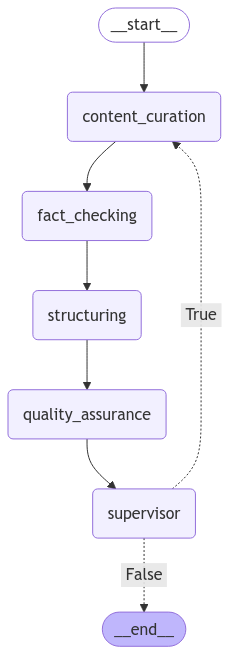

In [201]:
workflow.graph

In [202]:
result['final_output']

{'status': 'APPROVE',
 'decision_rationale': {'quality_standards_met': True,
  'fact_checking_complete': True,
  'structure_consistent': True,
  'coverage_balanced': True},
 'key_strengths': ['well-structured articles',
  'accurate reporting',
  'good source distribution'],
 'key_issues': ['low reliability score from AOL article'],
 'revision_requirements': ['no specific changes needed'],
 'final_articles': [{'title': "India's Maha Kumbh Mela: A look at the gigantic pitcher festival",
   'summary': 'The article reports on the Maha Kumbh Mela festival in India, where a stampede occurred, resulting in the deaths of more than seven people. The festival attracts millions of devotees and is considered one of the largest religious gatherings in the world.',
   'key_facts': ['More than seven people were killed in a stampede at the Maha Kumbh Mela'],
   'reliability_score': '90',
   'metadata': {'original_url': 'https://www.reuters.com/world/india/indias-maha-kumbh-mela-look-gigantic-pitcher-f